In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('blackjack_simulator.csv')

df.head()

,shoe_id,cards_remaining,dealer_up,initial_hand,dealer_final,dealer_final_value,player_final,player_final_value,actions_taken,run_count,true_count,win
0,0,416,10,"[10, 11]","[10, 4, 10]",24,"[[10, 11]]",['BJ'],[['S']],1,0,1.5
1,0,411,10,"[5, 5]","[10, 8]",18,"[[5, 5, 11]]",[21],"[['H', 'S']]",-2,0,1.0
2,0,406,6,"[3, 10]","[6, 6, 10]",22,"[[3, 10]]",[13],[['S']],-2,0,1.0
3,0,401,10,"[5, 9]","[10, 8]",18,"[[5, 9, 11, 3]]",[18],"[['H', 'H', 'S']]",-1,0,0.0
4,0,395,8,"[6, 10]","[8, 2, 10]",20,"[[6, 10, 10]]",[26],[['H']],-1,0,-1.0


In [3]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [4]:
df.nunique()

shoe_id               822845
cards_remaining          335
dealer_up                 10
initial_hand             100
dealer_final           38746
dealer_final_value        11
player_final          201731
player_final_value     13855
actions_taken           4957
run_count                 94
true_count                44
win                       19
dtype: int64

In [5]:
round((df.isnull().sum() / df.shape[0]) * 100, 2)

shoe_id              0.0000
cards_remaining      0.0000
dealer_up            0.0000
initial_hand         0.0000
dealer_final         0.0000
dealer_final_value   0.0000
player_final         0.0000
player_final_value   0.0000
actions_taken        0.0000
run_count            0.0000
true_count           0.0000
win                  0.0000
dtype: float64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
print((df['cards_remaining'] < 79).sum() + (df['cards_remaining'] > 416).sum())

0


In [8]:
valid = set(range(2, 12))
print((~df['dealer_up'].isin(valid)).sum())

0


In [9]:
print(round(df['true_count'].describe(), 2))

count   50000000.0000
mean           0.0300
std            2.0600
min          -22.0000
25%           -1.0000
50%            0.0000
75%            1.0000
max           22.0000
Name: true_count, dtype: float64


In [10]:
df[abs(df['true_count']) == 22]

,shoe_id,cards_remaining,dealer_up,initial_hand,dealer_final,dealer_final_value,player_final,player_final_value,actions_taken,run_count,true_count,win
1325425,21811,84,3,"[3, 3]","[3, 4, 10]",17,"[[3, 5, 7], [3, 2, 7, 4], [3, 6, 9]]","[15, 16, 18]","[['P', 'H', 'S'], ['P', 'H', 'H', 'S'], ['D']]",-36,-22,0.0000
42803714,704430,89,10,"[4, 10]","[10, 11]",BJ,"[[4, 10]]",[14],[[]],38,22,-1.0000
42803715,704430,85,10,"[5, 7]","[10, 10]",20,"[[5, 7, 10]]",[22],[['H']],36,22,-1.0000
42803716,704430,80,9,"[10, 10]","[9, 10]",19,"[[10, 10]]",[20],[['S']],34,22,1.0000


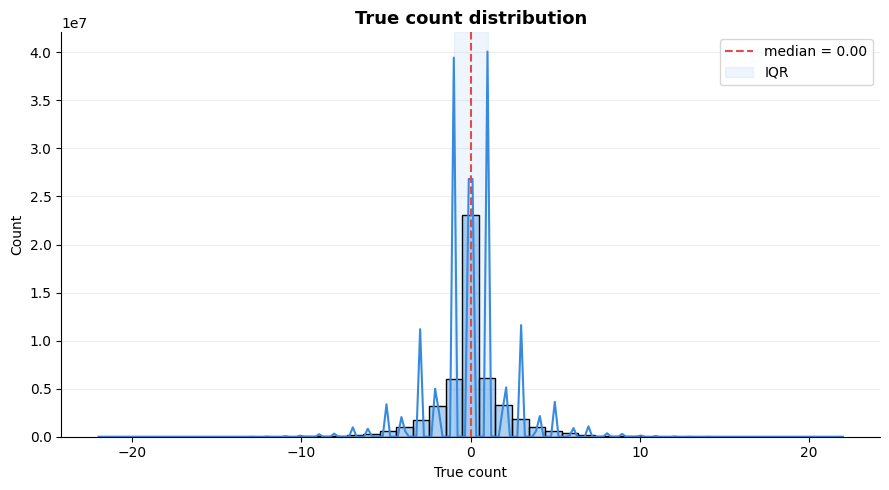

In [27]:
ig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df['true_count'], bins=45,
    kde=True, color='#378ADD',
    alpha=0.4, ax=ax)

med = df['true_count'].median()
ax.axvline(med, color='#E24B4A',
    linestyle='--', linewidth=1.5,
    label=f'median = {med:.2f}')

q1 = df['true_count'].quantile(.25)
q3 = df['true_count'].quantile(.75)
ax.axvspan(q1, q3, alpha=0.08,
    color='#378ADD', label='IQR')
ax.legend(fontsize=10)

ax.set_title('True count distribution',
    fontsize=13, fontweight='bold')
ax.set_xlabel('True count')
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, color='#eeeeee')
ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

<Axes: xlabel='true_count'>

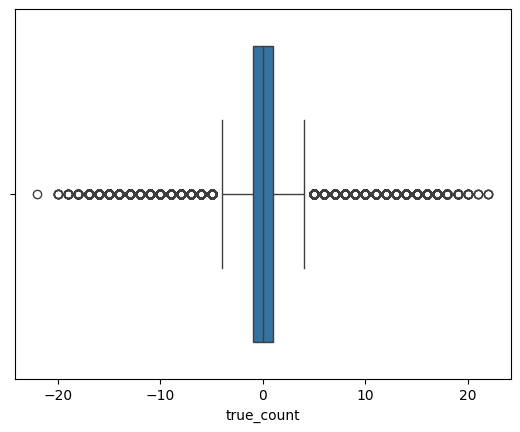

In [13]:
sns.boxplot(x=df["true_count"])

In [12]:
df['run_count'].describe()

count   50000000.0000
mean           0.1014
std            7.9826
min          -47.0000
25%           -5.0000
50%            0.0000
75%            5.0000
max           47.0000
Name: run_count, dtype: float64

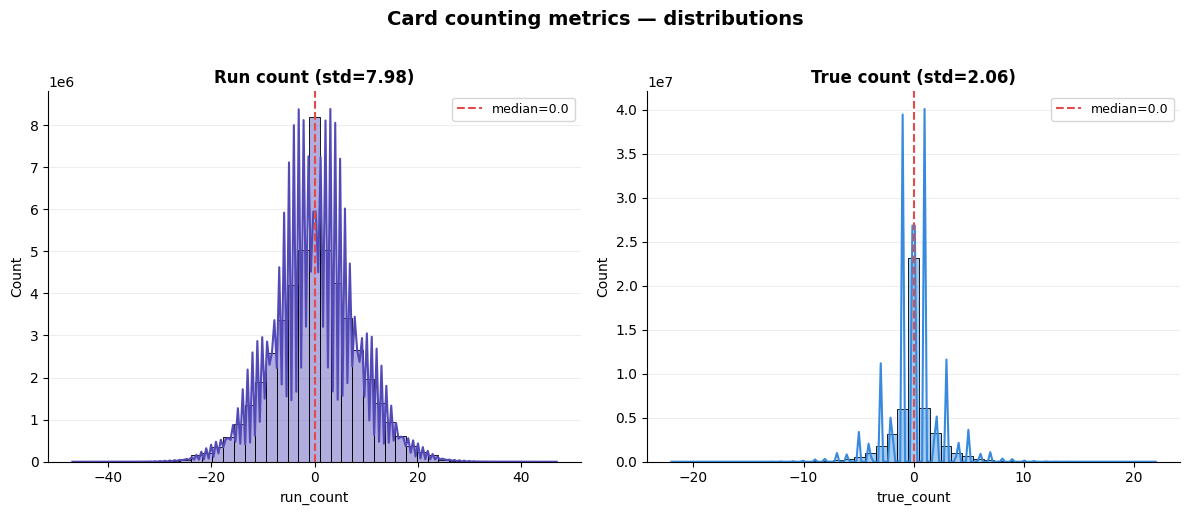

In [32]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    sharey=False
)

for ax, col, color, label in zip(
    axes,
    ['run_count', 'true_count'],
    ['#534AB7', '#378ADD'],
    ['Run count (std=7.98)',
     'True count (std=2.06)']
):
    sns.histplot(df[col], bins=45,
        kde=True, color=color,
        alpha=0.45, ax=ax)
    med = df[col].median()
    ax.axvline(med,
        color='#E24B4A', lw=1.5,
        linestyle='--',
        label=f'median={med:.1f}')
    ax.legend(fontsize=9)
    ax.set_title(label,
        fontsize=12, fontweight='bold')
    ax.spines[['top','right']]\
        .set_visible(False)
    ax.yaxis.grid(True,
        color='#eeeeee')
    ax.set_axisbelow(True)

fig.suptitle(
    'Card counting metrics — distributions',
    fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

<Axes: xlabel='run_count'>

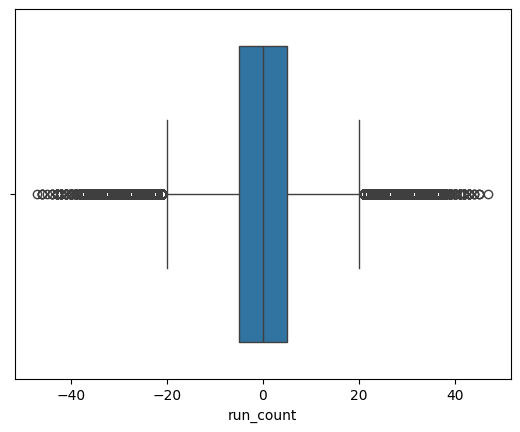

In [15]:
sns.boxplot(x=df["run_count"])

In [16]:
df['cards_remaining'].describe()

count   50000000.0000
mean         248.7133
std           98.2634
min           79.0000
25%          164.0000
50%          249.0000
75%          334.0000
max          416.0000
Name: cards_remaining, dtype: float64

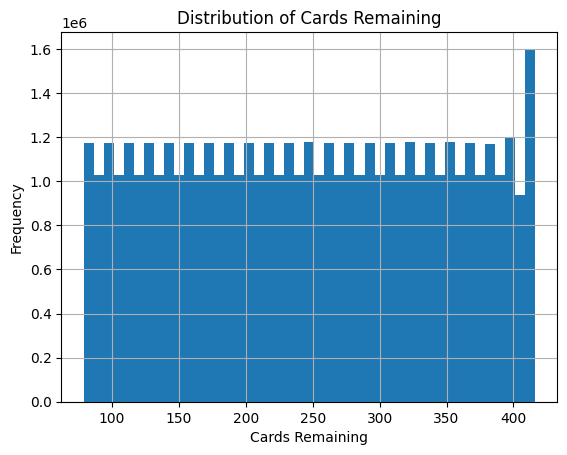

In [17]:
df['cards_remaining'].hist(bins=45)
plt.xlabel('Cards Remaining')
plt.ylabel('Frequency')
plt.title('Distribution of Cards Remaining')
plt.show()

In [18]:
df[["run_count", "true_count", "cards_remaining"]].corr()

,run_count,true_count,cards_remaining
run_count,1.0000,0.8615,-0.0069
true_count,0.8615,1.0000,-0.0130
cards_remaining,-0.0069,-0.0130,1.0000


In [56]:
df.to_parquet('blackjack_simulator.parquet', engine='pyarrow')

### Значение true_count напрямую влияет на ожидаемый выигрыш игрока

In [ ]:
from ast import literal_eval

df['initial_value'] = ( df['initial_hand'].apply(lambda x: sum(literal_eval(x))))

In [10]:
df['hand_strength'] = pd.cut(
    df['initial_value'],
    bins=[0,12,16,21],
    labels=[
        'Weak',
        'Medium',
        'Strong'
    ]
)

In [11]:
df['tc_group'] = pd.cut(
    df['true_count'],
    bins=[-22,-5,-1,1,5,22],
    labels=[
        'Very Low',
        'Low',
        'Neutral',
        'High',
        'Very High'
    ]
)

In [58]:
df['dealer_strength'] = df['dealer_up'].map({
    2: 'Weak', 3: 'Weak', 4: 'Weak', 5: 'Weak', 6: 'Weak',
    7: 'Strong', 8: 'Strong', 9: 'Strong', 10: 'Strong', 11: 'Strong'
})

In [ ]:
df.groupby(['hand_strength'])['win'].describe()

/var/folders/h6/zlbm8qr51p37fbd4gqph0fjw0000gn/T/ipykernel_11323/1770651071.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,count,mean,std,min,25%,50%,75%,max
hand_strength,,,,,,,,
Weak,15098347.0000,-0.0693,1.3495,-8.0000,-1.0000,-1.0000,1.0000,8.0000
Medium,17186483.0000,-0.3250,0.9620,-8.0000,-1.0000,-1.0000,1.0000,8.0000
Strong,17428158.0000,0.3592,0.9962,-6.0000,-1.0000,1.0000,1.0000,7.0000


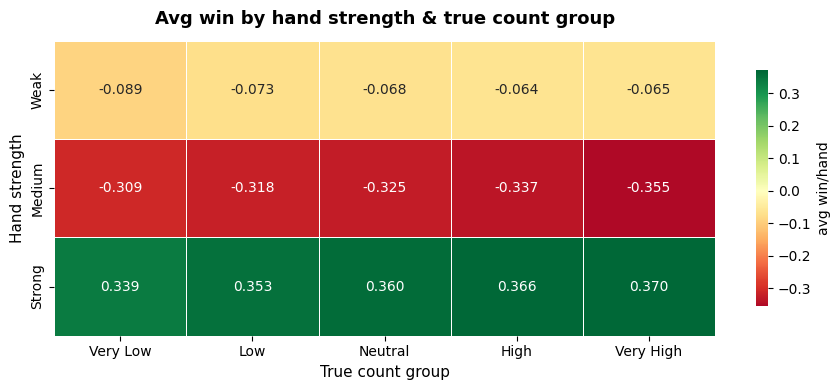

In [40]:
pivot = pd.pivot_table(
    df, values='win',
    index='hand_strength',
    columns='tc_group',
    aggfunc='mean',
    observed=False
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot,
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label':'avg win/hand',
              'shrink': 0.8},
    ax=ax)

ax.set_title(
    'Avg win by hand strength & true count group',
    fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('True count group', fontsize=11)
ax.set_ylabel('Hand strength', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

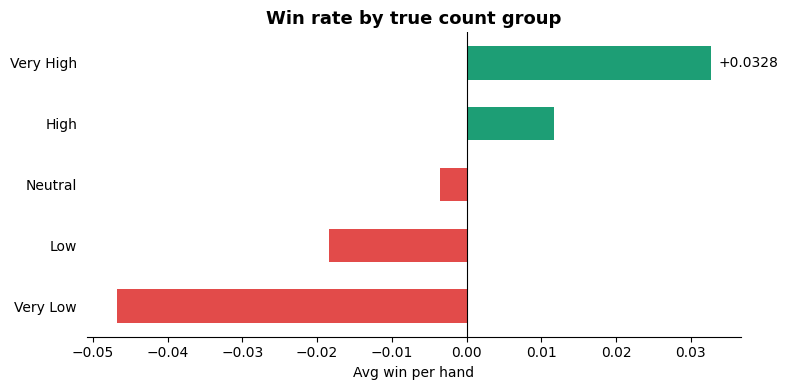

In [31]:
tc_profit = df.groupby( 'tc_group', observed=False )['win'].mean().sort_values() 
fig, ax = plt.subplots(figsize=(8, 4)) 


colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in tc_profit.values] 
bars = ax.barh(tc_profit.index, tc_profit.values, color=colors, height=0.55) 
ax.axvline(0, color='black', linewidth=0.8) 
for bar in bars: 
    v = bar.get_width() 


ax.text( v + (0.001 if v >= 0 else -0.001), bar.get_y() + bar.get_height()/2, f'{v:+.4f}', va='center', ha='left' if v >= 0 else 'right', fontsize=10 ) 
ax.set_xlabel('Avg win per hand') 
ax.set_title('Win rate by true count group', fontsize=13, fontweight='bold') 
ax.spines[['top','right', 'left']].set_visible(False) 
ax.tick_params(left=False) 
plt.tight_layout(); plt.show()

<Axes: xlabel='tc_group', ylabel='win'>

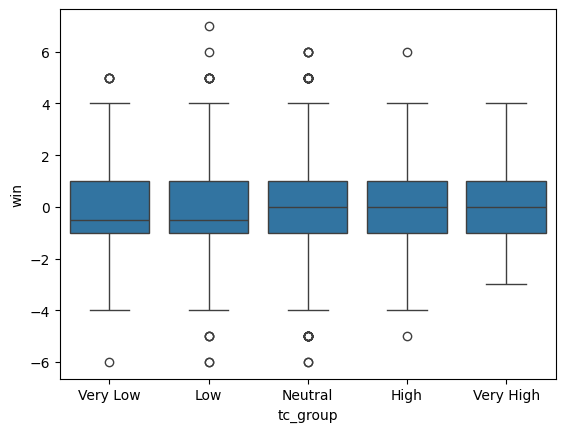

In [13]:
sns.boxplot(
    data=df.sample(200000),
    x='tc_group',
    y='win'
)

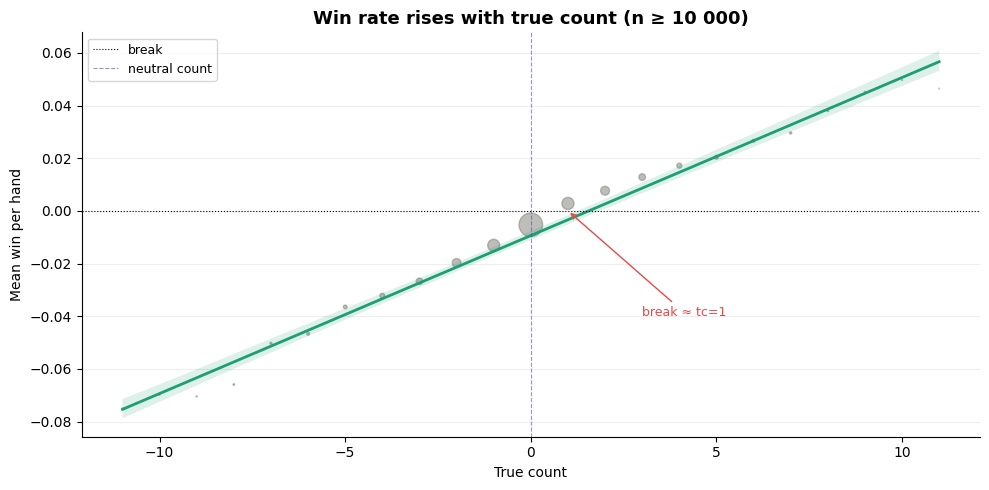

In [ ]:
minN = 10_000

tc_stats = (df.groupby('true_count')['win'].agg(['mean','count']).query('count >= @minN').reset_index())

fig, ax = plt.subplots(figsize=(10, 5))

sns.regplot( data=tc_stats,x='true_count',y='mean',
    scatter_kws={
        'alpha': 0.55,
        'color': '#888780',
        's': tc_stats['count'] / 80_000,
    },
    line_kws={
        'color': '#1D9E75',
        'linewidth': 2,
    },
    ci=95, ax=ax)

ax.axhline(0, color='black', lw=0.8, linestyle=':', label='break')
ax.axvline(0, color='#534AB7', lw=0.8, linestyle='--', alpha=0.6, label='neutral count')

slope = (tc_stats['mean'].iloc[-1] - tc_stats['mean'].iloc[0]) / (tc_stats['true_count'].iloc[-1] - tc_stats['true_count'].iloc[0])
ax.annotate( f'trend: {slope:+.4f} per count', xy=(8, 0.08), fontsize=10, color='#1D9E75', fontweight='bold')

crossover = tc_stats[ tc_stats['mean'] >= 0]['true_count'].min()
ax.annotate(f'break ≈ tc={crossover}', xy=(crossover, 0), xytext=(crossover + 2, -0.04),
    arrowprops=dict( arrowstyle='->', color='#E24B4A'), fontsize=9, color='#E24B4A')
ax.legend(fontsize=9)
ax.set_title( 'Win rate rises with true count (n ≥ 10 000)', fontsize=13, fontweight='bold')
ax.set_xlabel('True count')
ax.set_ylabel('Mean win per hand')
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True,color='#eeeeee')
ax.set_axisbelow(True)


plt.tight_layout(); plt.show()

/Users/afonin_egor/Desktop/Python_1_year/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/afonin_egor/Desktop/Python_1_year/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/afonin_egor/Desktop/Python_1_year/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


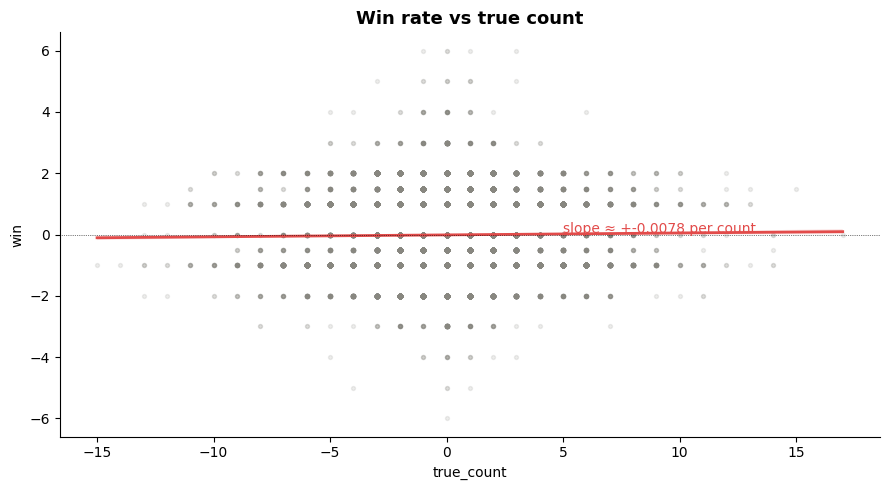

In [28]:
sample = df.sample(50000)
fig, ax = plt.subplots(figsize=(9, 5))

sns.regplot(data=sample,
    x='true_count', y='win',
    scatter_kws={'alpha':0.15,
                 'color':'#888780',
                 's':8},
    line_kws={'color':'#E24B4A',
              'linewidth':2},
    ci=95, ax=ax)

slope = df.groupby('true_count')['win']\
    .mean().diff().mean()
ax.annotate(
    f'slope ≈ +{slope:.4f} per count',
    xy=(5, 0.05), fontsize=10,
    color='#E24B4A')

ax.axhline(0, color='black',
    linewidth=0.5, linestyle=':')
ax.set_title('Win rate vs true count',
    fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

### Вероятность BJ повышается прямопропорционально значению true_count

In [33]:
df['blackjack'] = (
    df['player_final_value']
    .astype(str)
    .str.contains('BJ')
).astype(int)

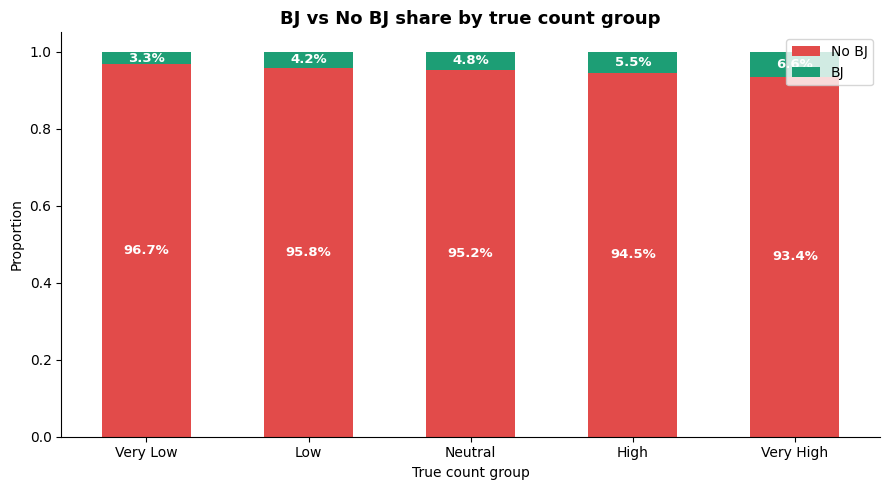

In [50]:
tc_order = ['Very Low','Low','Neutral','High','Very High']

ct = pd.crosstab( df['tc_group'], df['blackjack'], normalize='index' ).reindex(tc_order) 
ct.columns = ['No BJ','BJ'] 

fig, ax = plt.subplots(figsize=(9,5)) 

ct.plot( kind='bar', stacked=True, color=['#E24B4A','#1D9E75'], width=0.55, ax=ax ) 
cumulative = pd.Series( 0.0, index=ct.index) 

for col in ct.columns: 
    for i,(grp,val) in enumerate( ct[col].items()): 
        ax.text( i, cumulative[grp]+val/2, f'{val:.1%}', ha='center', va='center', fontsize=9.5, color='white', fontweight='bold' ) 
    cumulative += ct[col]


ax.set_title( 'BJ vs No BJ share by true count group', fontsize=13, fontweight='bold') 
ax.set_ylabel('Proportion') 
ax.set_xlabel('True count group') 
ax.set_xticklabels(tc_order, rotation=0)
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top','right']].set_visible(False) 


plt.tight_layout(); plt.show()

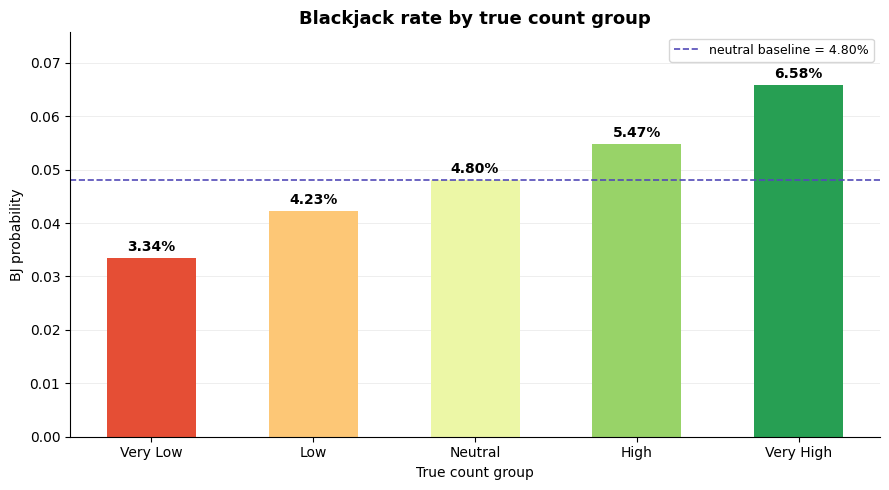

In [51]:
bj_rate = (df.groupby('tc_group',observed=False)['blackjack'].mean().reindex(tc_order))

fig, ax = plt.subplots(figsize=(9,5))

colors = plt.cm.RdYlGn( [0.15,0.35,0.55,0.72,0.88])

bars = ax.bar(bj_rate.index,bj_rate.values,color=colors, width=0.55)

for bar, val in zip(bars,bj_rate.values):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.0008,
        f'{val:.2%}',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold'
    )

baseline = bj_rate['Neutral']
ax.axhline(baseline, color='#534AB7', lw=1.2, linestyle='--',label=f'neutral baseline 'f'= {baseline:.2%}')
ax.legend(fontsize=9)

ax.set_title( 'Blackjack rate by true count group', fontsize=13, fontweight='bold')
ax.set_xlabel('True count group')
ax.set_ylabel('BJ probability')
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.7)
ax.set_axisbelow(True)
ax.set_ylim(0, bj_rate.max()*1.15)
plt.tight_layout(); plt.show()

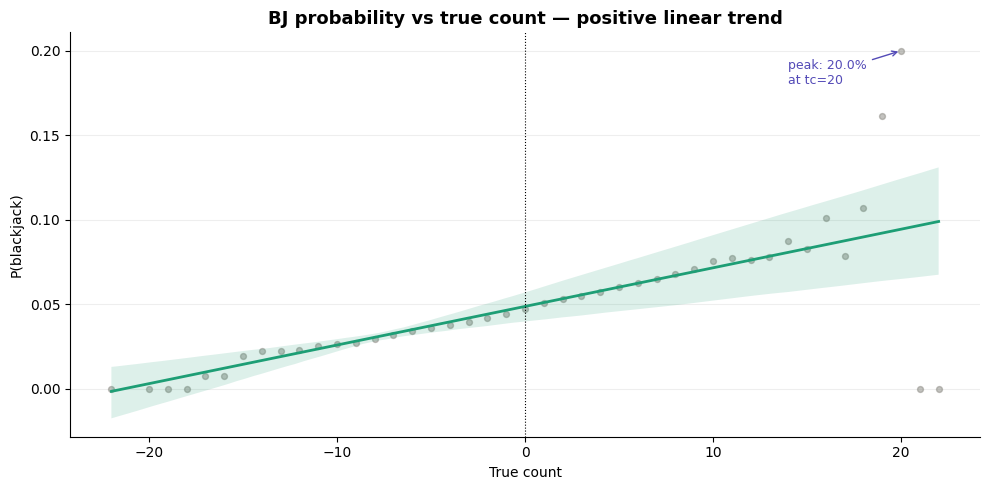

In [ ]:
bj_line = ( df.groupby('true_count') ['blackjack'].mean() .reset_index() ) 

fig, ax = plt.subplots(figsize=(10,5)) 
sns.regplot(data=bj_line, x='true_count', y='blackjack', 
            scatter_kws={ 'alpha': 0.5, 'color': '#888780', 's': 18 }, 
            line_kws={ 'color': '#1D9E75', 'linewidth': 2 }, ci=95, ax=ax)

peak = bj_line.loc[ bj_line['blackjack'].idxmax()] 


ax.annotate( f"peak: {peak['blackjack']:.1%}\n" 
            f"at tc={int(peak['true_count'])}", 
            xy=(peak['true_count'], peak['blackjack']), xytext=(peak['true_count']-6, peak['blackjack']-0.02), 
            arrowprops=dict( arrowstyle='->', color='#534AB7'), fontsize=9, color='#534AB7') 
ax.axvline(0, color='black', lw=0.8, linestyle=':') 
ax.set_title( 'BJ probability vs true count' ' — positive linear trend', fontsize=13, fontweight='bold') 
ax.set_xlabel('True count') 
ax.set_ylabel('P(blackjack)') 
ax.spines[['top','right']].set_visible(False) 
ax.yaxis.grid(True, color='#eeeeee') 
ax.set_axisbelow(True) 

plt.tight_layout(); plt.show()

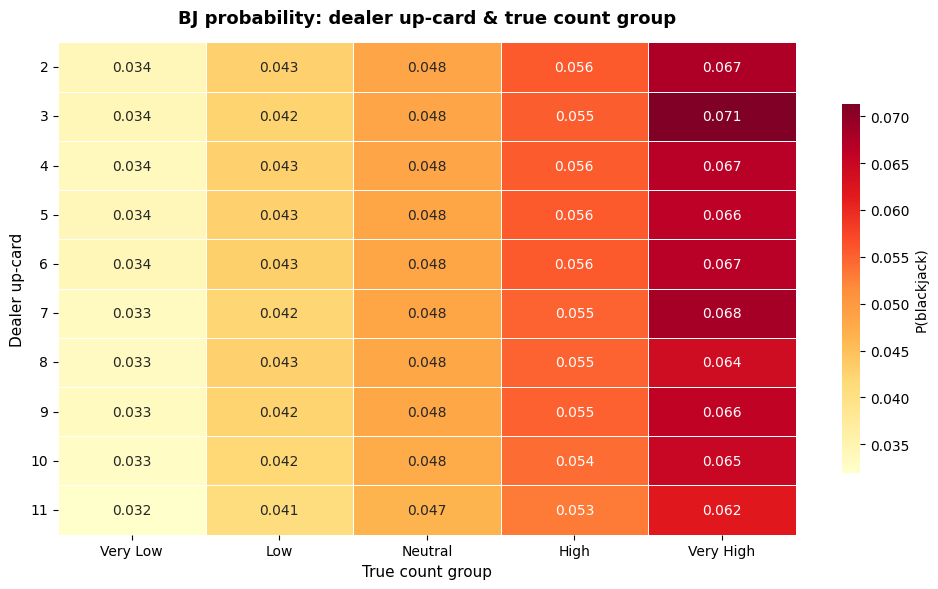

In [47]:
bj_heat = pd.pivot_table(
    df,
    values='blackjack',
    index='dealer_up',
    columns='tc_group',
    observed=False
)[tc_order]

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap( bj_heat, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.4, linecolor='white',
    cbar_kws={
        'label': 'P(blackjack)',
        'shrink': 0.75
    },
    ax=ax)

ax.set_title(
    'BJ probability: dealer up-card & true count group',
    fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('True count group', fontsize=11)
ax.set_ylabel('Dealer up-card', fontsize=11)
ax.tick_params( axis='x', rotation=0)
ax.tick_params( axis='y', rotation=0)


plt.tight_layout(); plt.show()

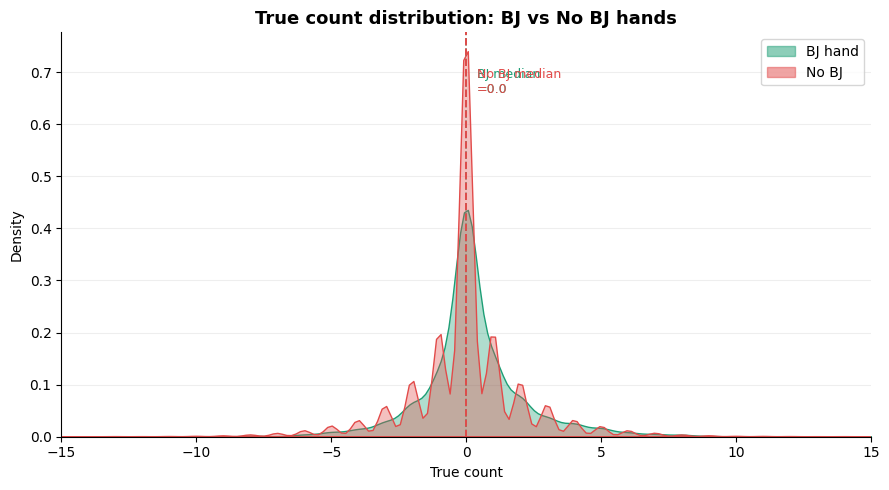

In [49]:
fig, ax = plt.subplots(figsize=(9,5))

sns.kdeplot(
    data=sample,
    x='true_count',
    hue='blackjack',
    fill=True,
    alpha=0.35,
    common_norm=False,
    palette={1:'#1D9E75', 0:'#E24B4A'},
    ax=ax
)

for val, color, lbl in [ (1,'#1D9E75','BJ'), (0,'#E24B4A','No BJ')]:
    med = df[df['blackjack']==val]['true_count'].median()
    ax.axvline(med, color=color, lw=1.4, linestyle='--')
    ax.text(med+0.4, ax.get_ylim()[1]*0.85, f'{lbl} median\n={med:.1f}',color=color, fontsize=9)

handles = [
    plt.matplotlib.patches.Patch(color='#1D9E75', alpha=0.5, label='BJ hand'),
    plt.matplotlib.patches.Patch( color='#E24B4A', alpha=0.5, label='No BJ')
]


ax.legend(handles=handles,fontsize=10)
ax.set_title('True count distribution: BJ vs No BJ hands', fontsize=13, fontweight='bold')
ax.set_xlabel('True count')
ax.spines[['top','right']].set_visible(False)
ax.yaxis.grid(True, color='#eeeeee')
ax.set_axisbelow(True)
ax.set_xlim(-15, 15)


plt.tight_layout(); plt.show()

<Axes: xlabel='blackjack', ylabel='true_count'>

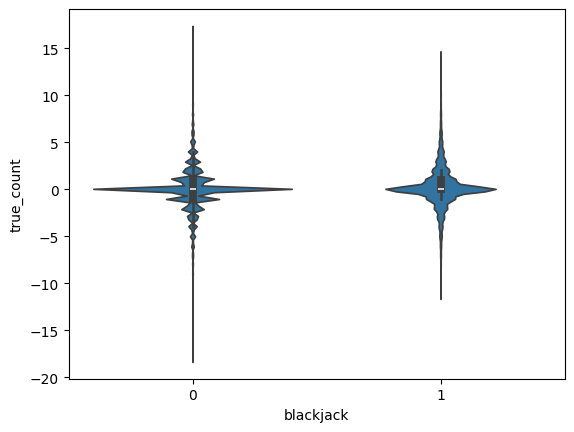

In [39]:
sns.violinplot(
    data=df.sample(200000),
    x='blackjack',
    y='true_count'
)

In [57]:
df.to_parquet('blackjack_simulator.parquet', engine='pyarrow')